# Sales Forecasting Using Python

This project uses historical sales data to forecast future sales using Python.

The dataset contains sales data from 2013 to 2017. In this project, 4 years of data from 2014 to 2017 is used for forecasting.

The main objective is to analyze sales trends, build machine learning models, compare model performance, and forecast sales for the next 30 days.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/plots", exist_ok=True)

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
df = pd.read_csv("train.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
Shape: (913000, 4)


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [ ]:
print("Column Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDataset Info:")
df.info()

Column Names:
Index(['date', 'store', 'item', 'sales'], dtype='object')

Missing Values:
date     0
store    0
item     0
sales    0
dtype: int64

Duplicate Rows:
0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [ ]:
df['date'] = pd.to_datetime(df['date'])

print("Full Dataset Start Date:", df['date'].min())
print("Full Dataset End Date:", df['date'].max())
print("Total Unique Days:", df['date'].nunique())

Full Dataset Start Date: 2013-01-01 00:00:00
Full Dataset End Date: 2017-12-31 00:00:00
Total Unique Days: 1826


In [ ]:
df_4years = df[(df['date'] >= '2014-01-01') & (df['date'] <= '2017-12-31')]

print("4 Years Dataset Shape:", df_4years.shape)
print("Start Date:", df_4years['date'].min())
print("End Date:", df_4years['date'].max())
print("Total Days:", df_4years['date'].nunique())

df_4years.head()

4 Years Dataset Shape: (730500, 4)
Start Date: 2014-01-01 00:00:00
End Date: 2017-12-31 00:00:00
Total Days: 1461


,date,store,item,sales
365,2014-01-01,1,1,9
366,2014-01-02,1,1,14
367,2014-01-03,1,1,11
368,2014-01-04,1,1,20
369,2014-01-05,1,1,17


In [ ]:
daily_sales = df_4years.groupby('date')['sales'].sum().reset_index()

print("Daily Sales Data:")
print(daily_sales.head())

print("\nShape:", daily_sales.shape)

Daily Sales Data:
        date  sales
0 2014-01-01  15556
1 2014-01-02  17033
2 2014-01-03  17746
3 2014-01-04  19184
4 2014-01-05  20182

Shape: (1461, 2)


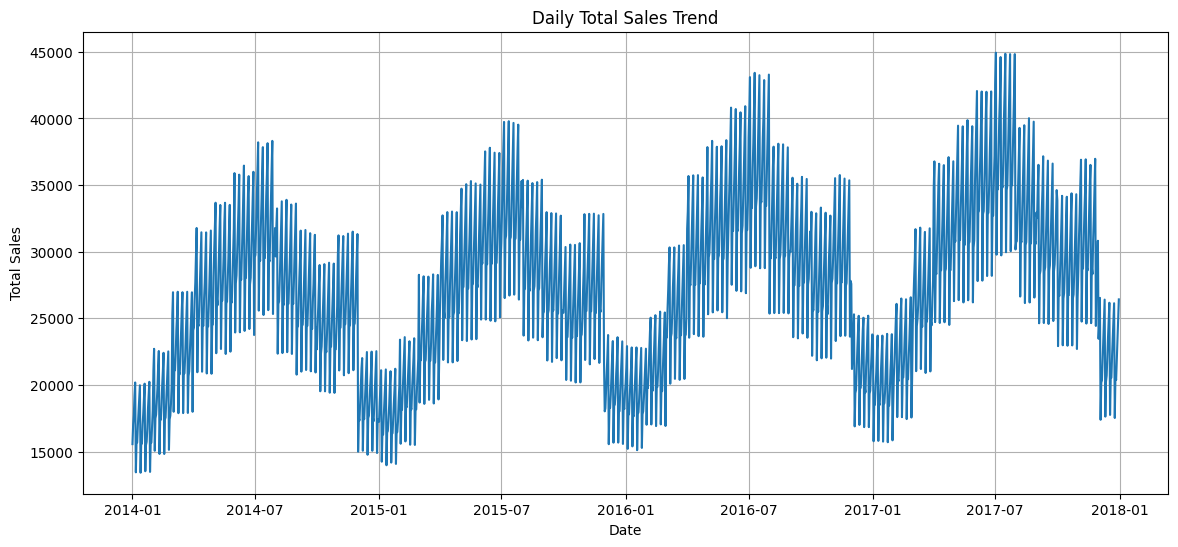

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(daily_sales['date'], daily_sales['sales'])
plt.title("Daily Total Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.savefig("outputs/plots/daily_sales_trend.png")
plt.show()

In [ ]:
daily_sales['year'] = daily_sales['date'].dt.year
daily_sales['month'] = daily_sales['date'].dt.month
daily_sales['day'] = daily_sales['date'].dt.day
daily_sales['day_of_week'] = daily_sales['date'].dt.dayofweek
daily_sales['quarter'] = daily_sales['date'].dt.quarter
daily_sales['week_of_year'] = daily_sales['date'].dt.isocalendar().week.astype(int)

daily_sales.head()

,date,sales,year,month,day,day_of_week,quarter,week_of_year
0,2014-01-01,15556,2014,1,1,2,1,1
1,2014-01-02,17033,2014,1,2,3,1,1
2,2014-01-03,17746,2014,1,3,4,1,1
3,2014-01-04,19184,2014,1,4,5,1,1
4,2014-01-05,20182,2014,1,5,6,1,1


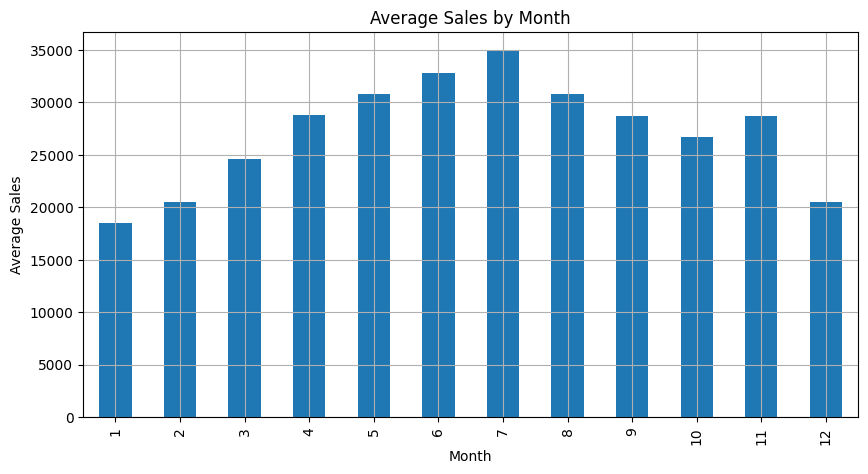

In [ ]:
monthly_sales = daily_sales.groupby('month')['sales'].mean()

plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='bar')
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.grid(True)
plt.savefig("outputs/plots/monthly_sales.png")
plt.show()

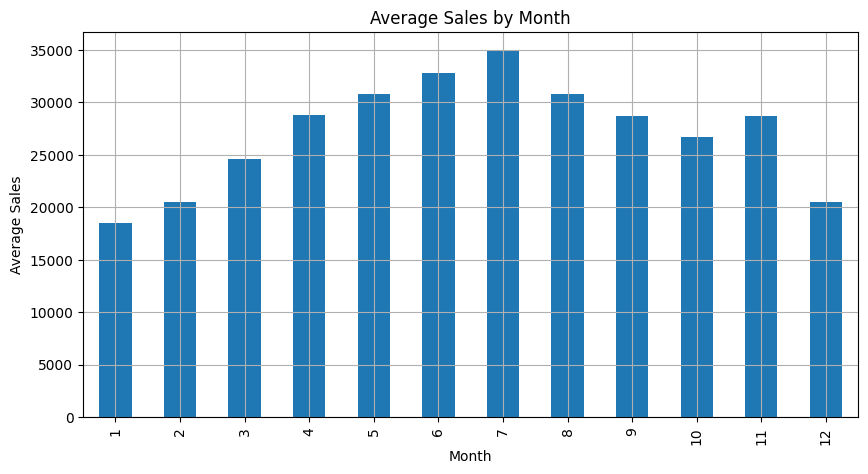

In [ ]:
monthly_sales = daily_sales.groupby('month')['sales'].mean()

plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='bar')
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.grid(True)
plt.savefig("outputs/plots/monthly_sales.png")
plt.show()

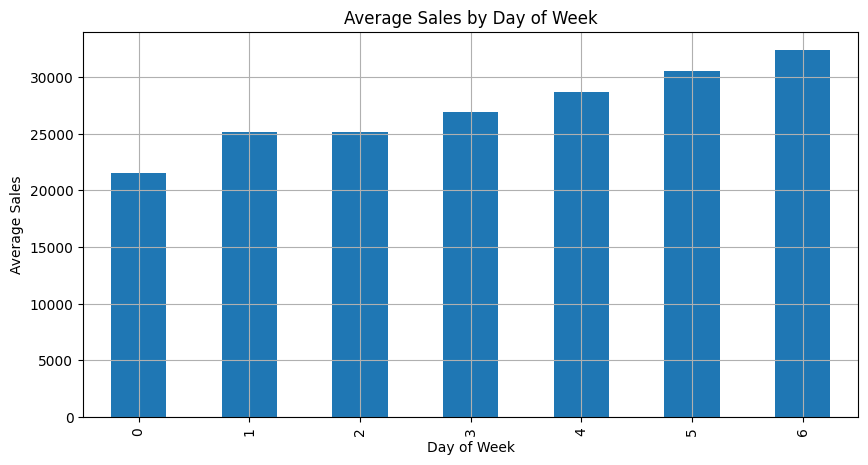

In [ ]:
day_sales = daily_sales.groupby('day_of_week')['sales'].mean()

plt.figure(figsize=(10, 5))
day_sales.plot(kind='bar')
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.grid(True)
plt.savefig("outputs/plots/day_wise_sales.png")
plt.show()

In [ ]:
daily_sales['sales_lag_1'] = daily_sales['sales'].shift(1)
daily_sales['sales_lag_7'] = daily_sales['sales'].shift(7)
daily_sales['sales_lag_14'] = daily_sales['sales'].shift(14)
daily_sales['sales_lag_30'] = daily_sales['sales'].shift(30)

daily_sales['rolling_mean_7'] = daily_sales['sales'].rolling(window=7).mean()
daily_sales['rolling_mean_14'] = daily_sales['sales'].rolling(window=14).mean()
daily_sales['rolling_mean_30'] = daily_sales['sales'].rolling(window=30).mean()

daily_sales['rolling_std_7'] = daily_sales['sales'].rolling(window=7).std()
daily_sales['rolling_std_30'] = daily_sales['sales'].rolling(window=30).std()

daily_sales = daily_sales.dropna()

print("Data after feature engineering:", daily_sales.shape)

daily_sales.head()

Data after feature engineering: (1431, 17)


,date,sales,year,month,day,day_of_week,quarter,week_of_year,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,rolling_std_30
30,2014-01-31,18073,2014,1,31,4,1,5,16899.0,18260.0,17888.0,15556.0,17034.428571,17002.357143,17014.366667,2317.526689,2082.217659
31,2014-02-01,21074,2014,2,1,5,1,5,18073.0,19179.0,18964.0,17033.0,17305.142857,17153.071429,17149.066667,2690.462378,2210.236638
32,2014-02-02,22709,2014,2,2,6,1,5,21074.0,20232.0,20093.0,17746.0,17659.000000,17339.928571,17314.500000,3245.258130,2431.153533
33,2014-02-03,15055,2014,2,3,0,1,6,22709.0,13469.0,13520.0,19184.0,17885.571429,17449.571429,17176.866667,2945.493046,2438.532200
34,2014-02-04,17488,2014,2,4,1,1,6,15055.0,15725.0,15484.0,20182.0,18137.428571,17592.714286,17087.066667,2801.831119,2372.767887


In [ ]:
features = [
    'year',
    'month',
    'day',
    'day_of_week',
    'quarter',
    'week_of_year',
    'sales_lag_1',
    'sales_lag_7',
    'sales_lag_14',
    'sales_lag_30',
    'rolling_mean_7',
    'rolling_mean_14',
    'rolling_mean_30',
    'rolling_std_7',
    'rolling_std_30'
]

X = daily_sales[features]
y = daily_sales['sales']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1431, 15)
y Shape: (1431,)


In [ ]:
test_size = 90

X_train = X.iloc[:-test_size]
X_test = X.iloc[-test_size:]

y_train = y.iloc[:-test_size]
y_test = y.iloc[-test_size:]

test_dates = daily_sales['date'].iloc[-test_size:]

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)
print("Test Start Date:", test_dates.min())
print("Test End Date:", test_dates.max())

Training Data Shape: (1341, 15)
Testing Data Shape: (90, 15)
Test Start Date: 2017-10-03 00:00:00
Test End Date: 2017-12-31 00:00:00


In [ ]:
def evaluate_model(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return {
        "Model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4),
        "MAPE": round(mape, 2)
    }

In [ ]:
models = {
    "Baseline Model": None,
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
}

predictions = {}
results = []

# Baseline: yesterday sales as today's prediction
baseline_pred = X_test['sales_lag_1']
predictions["Baseline Model"] = baseline_pred
results.append(evaluate_model(y_test, baseline_pred, "Baseline Model"))

for name, model in models.items():
    if model is not None:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        predictions[name] = pred
        results.append(evaluate_model(y_test, pred, name))

results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df

,Model,MAE,RMSE,R2 Score,MAPE
3,Gradient Boosting,547.06,993.16,0.9601,2.13
2,Random Forest,629.53,1339.98,0.9273,2.54
1,Linear Regression,717.57,1382.31,0.9227,2.85
0,Baseline Model,3108.08,4500.75,0.1803,12.66


In [ ]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

if best_model_name == "Baseline Model":
    best_prediction = predictions["Baseline Model"]
    best_model = None
else:
    best_prediction = predictions[best_model_name]
    best_model = models[best_model_name]

Best Model: Gradient Boosting


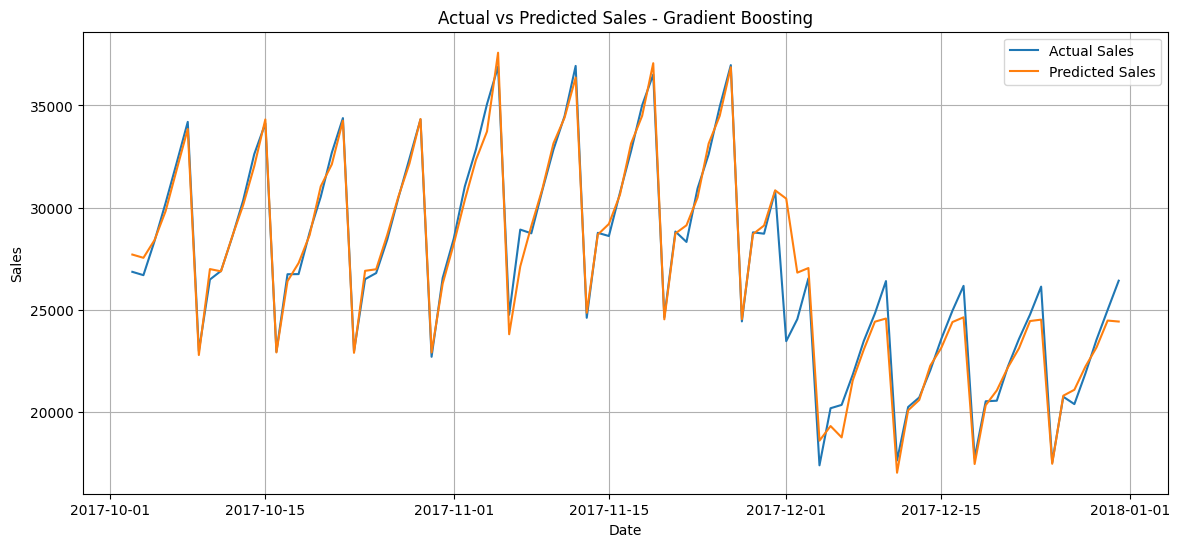

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test.values, label="Actual Sales")
plt.plot(test_dates, best_prediction, label="Predicted Sales")
plt.title(f"Actual vs Predicted Sales - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("outputs/plots/actual_vs_predicted_sales.png")
plt.show()

In [ ]:
prediction_result = pd.DataFrame({
    "date": test_dates.values,
    "actual_sales": y_test.values,
    "predicted_sales": best_prediction
})

prediction_result.to_csv("outputs/sales_prediction_result.csv", index=False)

prediction_result.head()

,date,actual_sales,predicted_sales
0,2017-10-03,26854,27699.406429
1,2017-10-04,26691,27540.825963
2,2017-10-05,28357,28406.512839
3,2017-10-06,30225,29824.089983
4,2017-10-07,32189,31852.886200


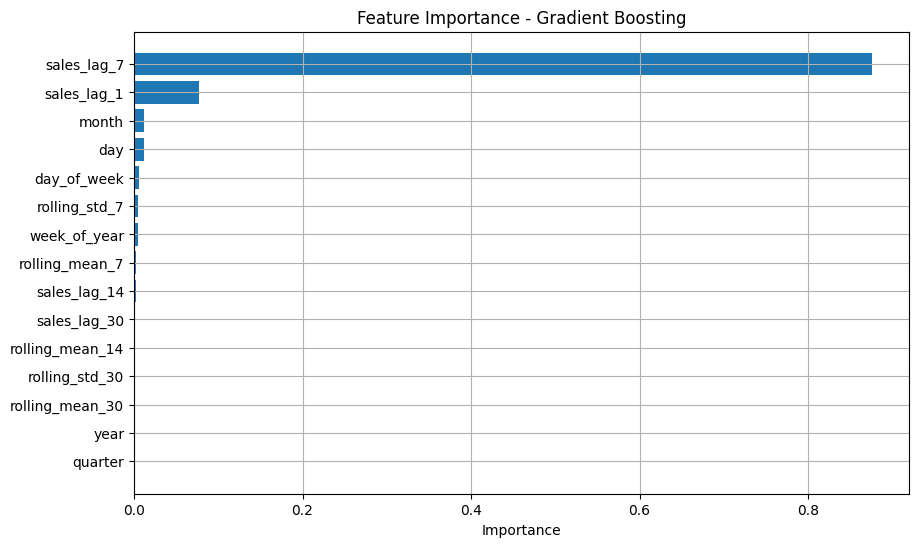

,Feature,Importance
7,sales_lag_7,0.875929
6,sales_lag_1,0.077148
1,month,0.012291
2,day,0.011414
3,day_of_week,0.005406
13,rolling_std_7,0.004929
5,week_of_year,0.004893
10,rolling_mean_7,0.002845
8,sales_lag_14,0.002208
9,sales_lag_30,0.001253


In [ ]:
if best_model is not None and hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": features,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.title(f"Feature Importance - {best_model_name}")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.grid(True)
    plt.savefig("outputs/plots/feature_importance.png")
    plt.show()

    display(importance_df)
else:
    print("Feature importance is not available for this model.")

In [ ]:
forecast_days = 30

history = daily_sales[['date', 'sales']].copy()
future_predictions = []

if best_model is None:
    model_for_forecast = models["Gradient Boosting"]
else:
    model_for_forecast = best_model

for i in range(forecast_days):
    next_date = history['date'].max() + pd.Timedelta(days=1)

    temp = pd.DataFrame({
        'date': [next_date],
        'year': [next_date.year],
        'month': [next_date.month],
        'day': [next_date.day],
        'day_of_week': [next_date.dayofweek],
        'quarter': [next_date.quarter],
        'week_of_year': [next_date.isocalendar().week],
        'sales_lag_1': [history['sales'].iloc[-1]],
        'sales_lag_7': [history['sales'].iloc[-7]],
        'sales_lag_14': [history['sales'].iloc[-14]],
        'sales_lag_30': [history['sales'].iloc[-30]],
        'rolling_mean_7': [history['sales'].iloc[-7:].mean()],
        'rolling_mean_14': [history['sales'].iloc[-14:].mean()],
        'rolling_mean_30': [history['sales'].iloc[-30:].mean()],
        'rolling_std_7': [history['sales'].iloc[-7:].std()],
        'rolling_std_30': [history['sales'].iloc[-30:].std()]
    })

    next_sales = model_for_forecast.predict(temp[features])[0]

    future_predictions.append({
        "date": next_date,
        "forecasted_sales": round(next_sales, 2)
    })

    new_row = pd.DataFrame({
        "date": [next_date],
        "sales": [next_sales]
    })

    history = pd.concat([history, new_row], ignore_index=True)

future_forecast = pd.DataFrame(future_predictions)

future_forecast.to_csv("outputs/next_30_days_sales_forecast.csv", index=False)

future_forecast

,date,forecasted_sales
0,2018-01-01,17532.33
1,2018-01-02,21194.92
2,2018-01-03,21066.11
3,2018-01-04,22093.66
4,2018-01-05,23282.37
5,2018-01-06,25508.74
6,2018-01-07,27357.13
7,2018-01-08,17692.70
8,2018-01-09,20868.91
9,2018-01-10,21049.36


In [ ]:
forecast_days = 30

history = daily_sales[['date', 'sales']].copy()
future_predictions = []

if best_model is None:
    model_for_forecast = models["Gradient Boosting"]
else:
    model_for_forecast = best_model

for i in range(forecast_days):
    next_date = history['date'].max() + pd.Timedelta(days=1)

    temp = pd.DataFrame({
        'date': [next_date],
        'year': [next_date.year],
        'month': [next_date.month],
        'day': [next_date.day],
        'day_of_week': [next_date.dayofweek],
        'quarter': [next_date.quarter],
        'week_of_year': [next_date.isocalendar().week],
        'sales_lag_1': [history['sales'].iloc[-1]],
        'sales_lag_7': [history['sales'].iloc[-7]],
        'sales_lag_14': [history['sales'].iloc[-14]],
        'sales_lag_30': [history['sales'].iloc[-30]],
        'rolling_mean_7': [history['sales'].iloc[-7:].mean()],
        'rolling_mean_14': [history['sales'].iloc[-14:].mean()],
        'rolling_mean_30': [history['sales'].iloc[-30:].mean()],
        'rolling_std_7': [history['sales'].iloc[-7:].std()],
        'rolling_std_30': [history['sales'].iloc[-30:].std()]
    })

    next_sales = model_for_forecast.predict(temp[features])[0]

    future_predictions.append({
        "date": next_date,
        "forecasted_sales": round(next_sales, 2)
    })

    new_row = pd.DataFrame({
        "date": [next_date],
        "sales": [next_sales]
    })

    history = pd.concat([history, new_row], ignore_index=True)

future_forecast = pd.DataFrame(future_predictions)

future_forecast.to_csv("outputs/next_30_days_sales_forecast.csv", index=False)

future_forecast

,date,forecasted_sales
0,2018-01-01,17532.33
1,2018-01-02,21194.92
2,2018-01-03,21066.11
3,2018-01-04,22093.66
4,2018-01-05,23282.37
5,2018-01-06,25508.74
6,2018-01-07,27357.13
7,2018-01-08,17692.70
8,2018-01-09,20868.91
9,2018-01-10,21049.36


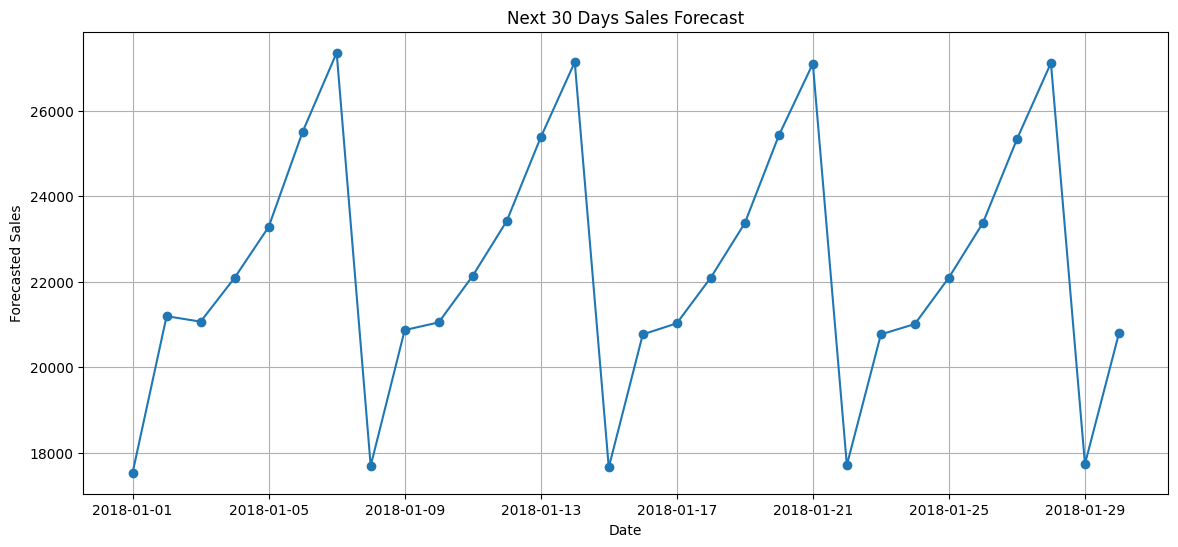

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(future_forecast['date'], future_forecast['forecasted_sales'], marker='o')
plt.title("Next 30 Days Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Forecasted Sales")
plt.grid(True)
plt.savefig("outputs/plots/next_30_days_forecast.png")
plt.show()

In [ ]:
if best_model is not None:
    with open("outputs/best_sales_forecasting_model.pkl", "wb") as file:
        pickle.dump(best_model, file)

    print("Best model saved successfully")
else:
    print("Baseline model was best, so no ML model saved.")

Best model saved successfully


In [ ]:
print("SALES FORECASTING PROJECT SUMMARY")
print("-" * 60)

print("Dataset used: Store Item Demand Forecasting dataset")
print("Full data range: 2013-01-01 to 2017-12-31")
print("Project data range: 2014-01-01 to 2017-12-31")
print("Forecasting level: Daily total sales")
print("Training method: Time-based split")
print("Testing period: Last 90 days")
print("Forecast period: Next 30 days")

print("\nModel Performance:")
display(results_df)

print("\nBest Model:", best_model_name)

print("""
Conclusion:
This project used 4 years of historical sales data to build a sales forecasting system.
The data was cleaned, converted into daily sales, and analyzed using visualizations.
Time-based features, lag features, and rolling statistics were created for forecasting.
Multiple machine learning models were trained and compared using MAE, RMSE, R2 Score, and MAPE.
The best performing model was selected and used to forecast the next 30 days of sales.
This type of project can help businesses in demand planning, inventory management, and sales strategy.
""")

SALES FORECASTING PROJECT SUMMARY
------------------------------------------------------------
Dataset used: Store Item Demand Forecasting dataset
Full data range: 2013-01-01 to 2017-12-31
Project data range: 2014-01-01 to 2017-12-31
Forecasting level: Daily total sales
Training method: Time-based split
Testing period: Last 90 days
Forecast period: Next 30 days

Model Performance:


,Model,MAE,RMSE,R2 Score,MAPE
3,Gradient Boosting,547.06,993.16,0.9601,2.13
2,Random Forest,629.53,1339.98,0.9273,2.54
1,Linear Regression,717.57,1382.31,0.9227,2.85
0,Baseline Model,3108.08,4500.75,0.1803,12.66



Best Model: Gradient Boosting

Conclusion:
This project used 4 years of historical sales data to build a sales forecasting system.
The data was cleaned, converted into daily sales, and analyzed using visualizations.
Time-based features, lag features, and rolling statistics were created for forecasting.
Multiple machine learning models were trained and compared using MAE, RMSE, R2 Score, and MAPE.
The best performing model was selected and used to forecast the next 30 days of sales.
This type of project can help businesses in demand planning, inventory management, and sales strategy.



In [ ]:
from google.colab import files

files.download("outputs/sales_prediction_result.csv")
files.download("outputs/next_30_days_sales_forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
from google.colab import files

readme_text = """
# Sales Forecasting Using Python

## Project Overview
This project uses historical sales data to forecast future sales using Python.
The dataset contains sales records of multiple stores and items.

## Dataset
Dataset used: Store Item Demand Forecasting dataset

The original dataset contains sales data from 2013 to 2017.
In this project, 4 years of data from 2014 to 2017 was used for forecasting.

## Objective
The objective of this project is to analyze historical sales data and build a machine learning model to forecast future sales.

## Tools and Libraries Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Google Colab

## Project Steps
1. Loaded the sales dataset
2. Checked missing values and dataset information
3. Converted date column into datetime format
4. Selected 4 years of historical sales data
5. Created daily total sales data
6. Performed exploratory data analysis
7. Created time-based, lag, and rolling features
8. Trained multiple machine learning models
9. Compared models using MAE, RMSE, R2 Score, and MAPE
10. Forecasted sales for the next 30 days

## Models Used
- Baseline Model
- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

## Evaluation Metrics
- MAE
- RMSE
- R2 Score
- MAPE

## Output
The project generates:
- Sales trend graph
- Monthly sales analysis
- Day-wise sales analysis
- Actual vs predicted sales graph
- Next 30 days sales forecast
- CSV files containing predictions

## Conclusion
This project shows how historical sales data can be used to predict future demand.
The forecasting model can help businesses in inventory planning, sales strategy, and demand management.
"""

requirements_text = """
pandas
numpy
matplotlib
scikit-learn
"""

with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme_text)

with open("requirements.txt", "w", encoding="utf-8") as file:
    file.write(requirements_text)

shutil.make_archive("sales_forecasting_project_outputs", "zip", "outputs")

files.download("sales_forecasting_project_outputs.zip")
files.download("README.md")
files.download("requirements.txt")

print("Project files created and downloaded successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Project files created and downloaded successfully.
